# Практическое занятие №6: Полный цикл разведочного анализа данных (EDA) на реальном датасете

## Ссылка на файл в гит репозитории

[Тык](https://github.com/MargQ/data_science_course/blob/master/6.%20sixth_lab/tasks.ipynb)

## Задание

Цель работы — выполнить полный цикл разведочного анализа данных (EDA)
для датасета flights и подготовить данные для дальнейшего прогнозирования.

Вариант 10: Flights (авиаперевозки)

Источник: ```sns.load_dataset('flights')```

Особенности данных: Временной ряд, задача — подготовка для
прогнозирования.

Задачи:
1. Преобразовать столбцы year и month в единый столбец date
типа datetime.
2. Создать признаки: month_num (число месяца), season (зима,
весна, лето, осень).
3. Заполнить пропуски (если есть) методом forward fill (ffill).
4. Создать лаговые признаки: passengers_lag1 (значение за
предыдущий месяц) с помощью shift().
5. Удалить дубликаты.


## Выполнение

### 1. Этап Discover (обнаружение)

На данном этапе выполняется загрузка данных,
первичный анализ структуры датасета,
а также поиск возможных проблем:
пропусков, дубликатов и выбросов.


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Загрузка датасета:

In [55]:
# Загрузка датасета
df = sns.load_dataset('flights')

Первичный осмотр (```info(), head(), describe()```):

In [48]:
# Первые строки
print("Первые 5 строк датасета:\n")
print(df.head())

# Информация о структуре
print("\nИнформация о датасете:\n")
print(df.info())

# Описательная статистика
print("\nОписательная статистика:")
print(df.describe(include='all'))

Первые 5 строк датасета:

   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121

Информация о датасете:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB
None

Описательная статистика:
               year month  passengers
count    144.000000   144  144.000000
unique          NaN    12         NaN
top             NaN   Jan         NaN
freq            NaN    12         NaN
mean    1954.500000   NaN  280.298611
std        3.464102   NaN  119.966317
min     1949.000000   NaN  104.000000
25%     1951.750000   NaN  180.000000
50%     1954.500000   NaN  265.500000
75%     1957.2500

Выявление проблем (пропуски, дубликаты, выбросы):

In [56]:
# Проверка пропусков
print("\nКоличество пропусков:")
print(df.isnull().sum())

# Проверка дубликатов
print("\nКоличество дубликатов:")
print(df.duplicated().sum())



Количество пропусков:
year          0
month         0
passengers    0
dtype: int64

Количество дубликатов:
0


### Вывод

Датасет содержит информацию о количестве авиапассажиров по месяцам.
В датасете отсутствуют пропущенные значения и дубликаты.

### 2. Этап Structure (структурирование)

На данном этапе выполняется преобразование типов данных,
создание столбца даты и подготовка структуры датасета
для дальнейшего анализа временного ряда.

In [57]:
# Переименование столбца passengers
df.rename(columns={'passengers': 'passenger_count'}, inplace=True)

# Создание номера месяца
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3,
    'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9,
    'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Создаем столбец month_num для datetime
df['month_num'] = df['month'].map(month_map)

# Создание datetime
df['date'] = pd.to_datetime (dict (year=df['year'], month=df['month_num'], day=1))

# Настройка индекса
df.set_index('date', inplace=True)

print(df.head())
print(df.dtypes)

            year month  passenger_count month_num
date                                             
1949-01-01  1949   Jan              112         1
1949-02-01  1949   Feb              118         2
1949-03-01  1949   Mar              132         3
1949-04-01  1949   Apr              129         4
1949-05-01  1949   May              121         5
year                  int64
month              category
passenger_count       int64
month_num          category
dtype: object


### Вывод

На этапе структурирования были преобразованы признаки датасета
для более удобной работы с временным рядом.

Столбцы year и month были объединены в единый datetime-признак date. Для создания признака date был добавлен первый день месяца,
так как исходный датасет содержит только информацию о месяце и годе.


Столбец date был установлен в качестве индекса,
так как данные представляют собой временной ряд.


### 3. Этап Clean (очистка)

На данном этапе выполняется обработка пропусков,
удаление дубликатов и проверка выбросов методом IQR:

In [58]:
# Forward fill для пропусков
df = df.ffill()

# Удаление дубликатов
duplicates_before = df.duplicated().sum()

df.drop_duplicates(inplace=True)

duplicates_after = df.duplicated().sum()

print("Дубликатов до удаления:", duplicates_before)
print("Дубликатов после удаления:", duplicates_after)

Дубликатов до удаления: 0
Дубликатов после удаления: 0


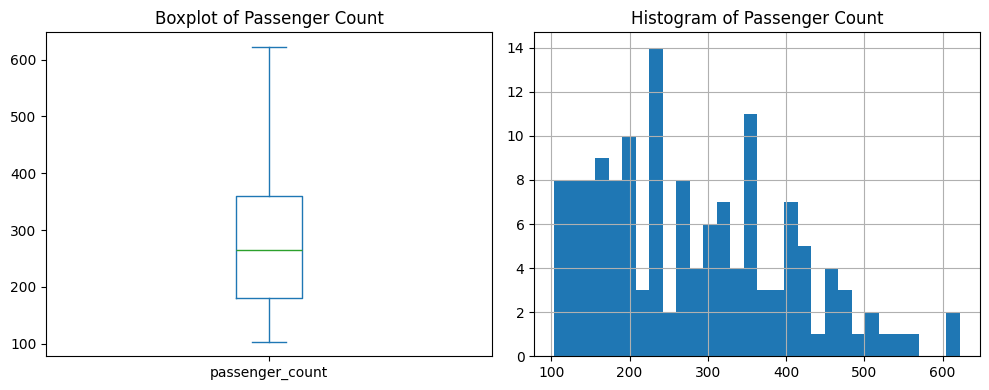

In [41]:
# Boxplot и histogram
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
df['passenger_count'].plot(kind='box')
plt.title('Boxplot of Passenger Count')

plt.subplot(1,2,2)
df['passenger_count'].hist(bins=30)
plt.title('Histogram of Passenger Count')

plt.tight_layout()
plt.show()

### Вывод

На этапе очистки были проверены пропуски, дубликаты и возможные выбросы.
Анализ показал, что пропущенные значения и дубликаты в датасете отсутствуют.

Для проверки выбросов были построены boxplot и histogram
для признака passenger_count. Явных выбросов обнаружено не было, поэтому дополнительная обработка выбросов не потребовалась.

### 4. Этап Enrich (обогащение)

На данном этапе создаются новые признаки,
которые могут быть полезны для анализа
и прогнозирования временного ряда.

In [59]:
# month_map был создан ранее для datetime
#df['month_num'] = df['month'].map(month_map)

# Сезон
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

df['season'] = df['month_num'].apply(get_season)

# Лаговый признак
df['passengers_lag1'] = df['passenger_count'].shift(1)

# Удаление столбцов year и month
df = df.drop(columns=['year', 'month'])


print(df.head())


            passenger_count month_num  season  passengers_lag1
date                                                          
1949-01-01              112         1  winter              NaN
1949-02-01              118         2  winter            112.0
1949-03-01              132         3  spring            118.0
1949-04-01              129         4  spring            132.0
1949-05-01              121         5  spring            129.0


### Вывод

Был создан числовой признак month_num, который упрощает дальнейший анализ сезонности. После создания datetime-признака исходные столбцы year и month были удалены, поскольку информация о них уже содержится в date.

А также создан признак season, отражающий сезон года (winter, spring, summer, autumn).

Был создан лаговый признак passengers_lag1, который содержит значение passenger_count за предыдущий месяц.

### 5. Этап Validate (валидация)

На данном этапе выполняется финальная проверка корректности данных
после всех преобразований и очистки.

In [60]:
print("Пропуски после обработки:")
print(df.isnull().sum())

print("\nМинимальное значение passenger_count:")
print(df['passenger_count'].min())

print("\nМаксимальное значение passenger_count:")
print(df['passenger_count'].max())

print("\nПервые строки итогового датасета:")
print(df.head())

Пропуски после обработки:
passenger_count    0
month_num          0
season             0
passengers_lag1    1
dtype: int64

Минимальное значение passenger_count:
104

Максимальное значение passenger_count:
622

Первые строки итогового датасета:
            passenger_count month_num  season  passengers_lag1
date                                                          
1949-01-01              112         1  winter              NaN
1949-02-01              118         2  winter            112.0
1949-03-01              132         3  spring            118.0
1949-04-01              129         4  spring            132.0
1949-05-01              121         5  spring            129.0


Первое значение passengers_lag1 содержит пропуск, так как для первого месяца отсутствует предыдущее наблюдение.Диапазон значений passenger_count остаётся корректным,отрицательные значения отсутствуют.

In [61]:
# Сохранение очищенного датасета
df.to_csv('cleaned_flights.csv')

print("Файл cleaned_flights.csv успешно сохранён")

Файл cleaned_flights.csv успешно сохранён


Итоговый датасет подготовлен для дальнейшего анализа
и прогнозирования временного ряда.

### Итоговый вывод


В ходе работы был выполнен полный цикл предобработки и разведочного анализа датасета flights.

Были проведены этапы обнаружения, структурирования, очистки, обогащения и валидации данных.
Для подготовки временного ряда к дальнейшему прогнозированию был создан datetime-признак date, а также новые признаки:
month_num, season и passengers_lag1. 

Итоговый датасет был успешно подготовлен
для дальнейшего анализа и построения моделей прогнозирования.